In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
TRAIN_FILE  = "salary_data.xlsx"
OUTPUT_FILE = "prediction_output.xlsx"
 
sample = pd.DataFrame({
    "Experience": [1, 3, 4, 6, 8],
    "Salary":     [20, 40, 50, 70, 90]
})
sample.to_excel(TRAIN_FILE, index=False)

In [11]:
df      = pd.read_excel(TRAIN_FILE)
X       = df[["Experience"]].values
y       = df["Salary"].values
model   = LinearRegression()
model.fit(X, y)
history = []
print("AI Agent Trained Successfully")
print(f"Using data from: {TRAIN_FILE}")

AI Agent Trained Successfully
Using data from: salary_data.xlsx


In [12]:
def predict(X_new):
    return model.predict(X_new)

In [13]:
def interact():
    years = float(input("Enter years of experience: "))
    if years < 0:
        print("Invalid input: Years of experience cannot be negative.")
        return
    prediction = predict([[years]])[0]
    print(f"Predicted Salary for {years} years = ₹{prediction:.2f}k")
    history.append([years, prediction])

In [14]:
def visualize_scatter():
    df     = pd.DataFrame(history, columns=["Experience", "Predicted Salary"])
    X_h    = df[["Experience"]].values
    y_h    = df["Predicted Salary"].values
    m      = LinearRegression()
    m.fit(X_h, y_h)
    y_pred = m.predict(X_h)
 
    sort_idx      = X_h.flatten().argsort()
    X_sorted      = X_h[sort_idx]
    y_pred_sorted = y_pred[sort_idx]
 
    plt.figure()
    plt.scatter(X_h, y_h, color="green", label="Predicted Data")
    plt.plot(X_sorted, y_pred_sorted, color="red", label="Regression Line")
    plt.xlabel("Experience (years)")
    plt.ylabel("Predicted Salary (₹k)")
    plt.title("Predicted Salary vs Experience")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
for i in range(10):
    interact()

Predicted Salary for 1.0 years = ₹20.00k
Predicted Salary for 2.0 years = ₹30.00k
Predicted Salary for 3.0 years = ₹40.00k
Predicted Salary for 4.0 years = ₹50.00k
Predicted Salary for 5.0 years = ₹60.00k
Predicted Salary for 6.0 years = ₹70.00k
Predicted Salary for 7.0 years = ₹80.00k
Predicted Salary for 8.0 years = ₹90.00k
Predicted Salary for 9.0 years = ₹100.00k
Predicted Salary for 10.0 years = ₹110.00k


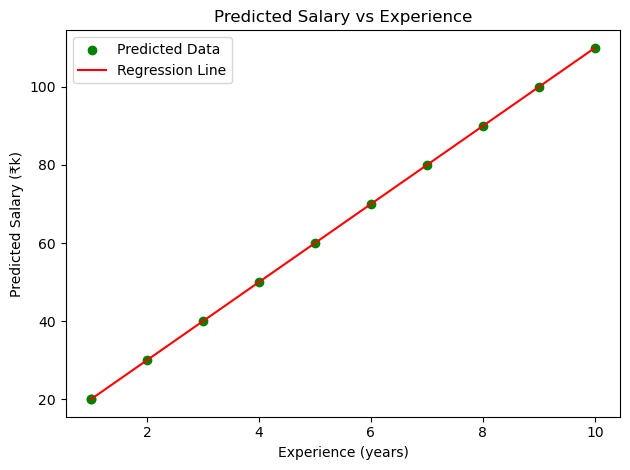

In [ ]:
visualize_scatter()